<a href="https://colab.research.google.com/github/debo-ogunnowo/Prompt-Inference-System/blob/main/prompt_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets scikit-learn torch -q

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [ ]:
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU available: True
Device: Tesla T4


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/FYP/final_prompt_data_labeled.csv')
print(df.shape)
print(df['Category'].value_counts())
print(df.head())

(1218, 2)
Category
Research&Inquiry      550
Content Generation    362
Text Refinement       306
Name: count, dtype: int64
                                              Prompt          Category
0                      What is problem solving in AI  Research&Inquiry
1  Problem solving in AI. Minimax with Alphabeta ...  Research&Inquiry
2  Let's take it slower and one topic at a time. ...  Research&Inquiry
3  Good day. I have an idea. I want to create an ...  Research&Inquiry
4  How exactly does the system perform dynamic sc...  Research&Inquiry


In [ ]:
print(df.isnull().sum())
print(df['Category'].unique())

Prompt      0
Category    0
dtype: int64
['Research&Inquiry' 'Content Generation' 'Text Refinement']


In [ ]:
df['Category'] = df['Category'].str.strip()
label_map = {
  'Research&Inquiry': 0,
  'Content Generation': 1,
  'Text Refinement': 2
}

df['label'] = df['Category'].map(label_map)
print(df['label'].value_counts())

label
0    550
1    362
2    306
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df,
                                     test_size=0.2,
                                     random_state=SEED,
                                     stratify=df['label'])

train_df, val_df = train_test_split(train_df,
                                   test_size=0.1,
                                   random_state=SEED,
                                   stratify=train_df['label'])

print("Train:", train_df['label'].value_counts())
print("Validation:", val_df['label'].value_counts())
print("Test:", test_df['label'].value_counts())



Train: label
0    396
1    260
2    220
Name: count, dtype: int64
Validation: label
0    44
1    29
2    25
Name: count, dtype: int64
Test: label
0    110
1     73
2     61
Name: count, dtype: int64


In [ ]:
train_set = pd.concat([train_df, val_df], axis=0, ignore_index=True)
print(train_set.shape)
print(train_set['Category'].value_counts())

(974, 3)
Category
Research&Inquiry      440
Content Generation    289
Text Refinement       245
Name: count, dtype: int64


In [ ]:
from transformers import AutoTokenizer

model = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model)

def tokenize(texts, labels, max_length=128):
  encodings = tokenizer(
      list(texts),
      truncation=True,
      padding='max_length',
      max_length=max_length,
      return_tensors='pt'
  )
  return encodings, torch.tensor(list(labels))

train_encodings, train_labels = tokenize(train_df['Prompt'], train_df['label'])
val_encodings, val_labels = tokenize(val_df['Prompt'], val_df['label'])
test_encodings, test_labels = tokenize(test_df['Prompt'], test_df['label'])


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
from torch.utils.data import Dataset

class PromptDataset(Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = labels

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    item = {key: val[idx] for key, val in self.encodings.items()}
    item['labels'] = self.labels[idx]
    return item

train_dataset = PromptDataset(train_encodings, train_labels)
val_dataset = PromptDataset(val_encodings, val_labels)
test_dataset = PromptDataset(test_encodings, test_labels)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(model, num_labels=3)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=1)
  macro_f1 = f1_score(labels, predictions, average='macro')
  return {'macro_f1': macro_f1}

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    logging_steps=10,
    seed=SEED,
    fp16=True,
)

In [ ]:
from torch import nn
from transformers import Trainer

class_counts = train_df['label'].value_counts().sort_index().values
class_weights = torch.tensor(
    1.0 / class_counts,
    dtype=torch.float
)
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to('cuda' if torch.cuda.is_available() else 'cpu')

class WeightedTrainer(Trainer):
  def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
    labels = inputs.pop("labels")
    outputs = model(**inputs)
    logits = outputs.logits
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    loss = loss_fn(logits, labels)
    return (loss, outputs) if return_outputs else loss


In [ ]:
#Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Macro F1
1,0.384963,0.470660,0.831433
2,0.190216,0.485429,0.858136
3,0.103457,0.490403,0.869281


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=165, training_loss=0.31409144473798345, metrics={'train_runtime': 56.0744, 'train_samples_per_second': 46.866, 'train_steps_per_second': 2.943, 'total_flos': 172865515447296.0, 'train_loss': 0.31409144473798345, 'epoch': 3.0})

In [ ]:
#Eval
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

reverse_label_map = {0: 'Research&Inquiry', 1: 'Content Generation', 2: 'Text Refinement'}
pred_labels = [reverse_label_map[p] for p in preds]
true_labels = [reverse_label_map[l] for l in labels]

print(classification_report(true_labels, pred_labels, digits=4))

                    precision    recall  f1-score   support

Content Generation     0.9275    0.8767    0.9014        73
  Research&Inquiry     0.9286    0.9455    0.9369       110
   Text Refinement     0.9683    1.0000    0.9839        61

          accuracy                         0.9385       244
         macro avg     0.9415    0.9407    0.9407       244
      weighted avg     0.9382    0.9385    0.9380       244



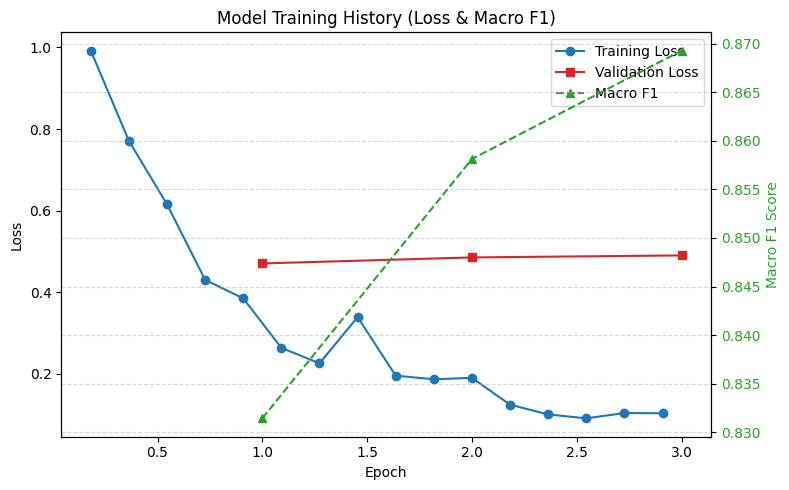

In [ ]:
import matplotlib.pyplot as plt

# Extract metrics from Trainer log history
history = trainer.state.log_history

epochs_eval = [x['epoch'] for x in history if 'eval_loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
macro_f1 = [x['eval_macro_f1'] for x in history if 'eval_macro_f1' in x]

epochs_train = [x['epoch'] for x in history if 'loss' in x]
train_loss = [x['loss'] for x in history if 'loss' in x]

# Plot
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
l1 = ax1.plot(epochs_train, train_loss, label='Training Loss', color='#1f77b4', marker='o')
l2 = ax1.plot(epochs_eval, val_loss, label='Validation Loss', color='#d62728', marker='s')

ax2 = ax1.twinx()
ax2.set_ylabel('Macro F1 Score', color='#2ca02c')
l3 = ax2.plot(epochs_eval, macro_f1, label='Macro F1', color='#2ca02c', marker='^', linestyle='--')
ax2.tick_params(axis='y', labelcolor='#2ca02c')

lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.title('Model Training History (Loss & Macro F1)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

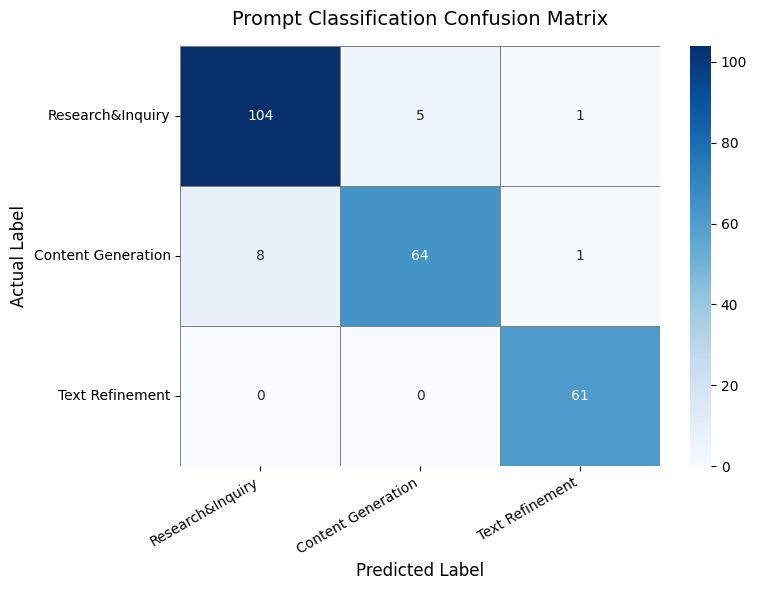

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

class_names = ['Research&Inquiry', 'Content Generation', 'Text Refinement']

# confusion matrix
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Prompt Classification Confusion Matrix', fontsize=14, pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
#print("Confusion matrix saved.")

In [ ]:
# #Save model
#plt.savefig('/content/drive/MyDrive/prompt_classifier_v2/confusion_matrix.png', dpi=150, bbox_inches='tight')
#model.save_pretrained('/content/drive/MyDrive/prompt_classifier_v1')
#tokenizer.save_pretrained('/content/drive/MyDrive/prompt_classifier_v1')
print("Model saved.")

Model saved.


In [ ]:
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model=model,  # Use the trained model object directly
    tokenizer=tokenizer, # Use the trained tokenizer object directly
    device=0 if torch.cuda.is_available() else -1
)

label_display = {
    'LABEL_0': 'Research and Inquiry',
    'LABEL_1': 'Content Generation',
    'LABEL_2': 'Text Refinement'
}

def classify_prompt(prompt):
  result = classifier(prompt)[0]
  label = label_display[result['label']]
  confidence = round(result['score'], 4)
  return {'category': label, 'confidence': confidence}

In [ ]:
# Overfitting Test

from sklearn.metrics import f1_score
from torch.utils.data import DataLoader
import torch
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Evaluate on training set
train_loader = DataLoader(train_dataset, batch_size=16)
train_preds = []
train_true = []

model.eval()
with torch.no_grad():
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        batch_labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=-1)
        train_preds.extend(preds.cpu().numpy())
        train_true.extend(batch_labels.cpu().numpy())

train_f1 = f1_score(train_true, train_preds, average='macro')

# Evaluate on test set to get the actual test_f1
test_predictions = trainer.predict(test_dataset)
test_preds = np.argmax(test_predictions.predictions, axis=1)
test_true = test_predictions.label_ids
test_f1 = f1_score(test_true, test_preds, average='macro')

print(f"Training Macro F1:    {train_f1:.4f}")
print(f"Test Macro F1:        {test_f1:.4f}")
print(f"Gap:                  {train_f1 - test_f1:.4f}")

Training Macro F1:    0.9842
Test Macro F1:        0.9407
Gap:                  0.0434


In [ ]:
print(classify_prompt("Are there any scanning/raster type display technologies other than CRTs? Are any still in production for consumers today, or anything similar?"))
print(classify_prompt("Search european folktales which their purported origins in the neolithic. Also search the origins of christmas and christmas traditions. Try to find any pattern or motif that could be evidence of the origins of any christmas traditions in the neolithic"))
print(classify_prompt("rewrite this paragraph to sound more academic"))

{'category': 'Research and Inquiry', 'confidence': 0.9867}
{'category': 'Content Generation', 'confidence': 0.9696}
{'category': 'Text Refinement', 'confidence': 0.9737}
